## NLP for Social Media Hate Speech Recognition

- **Author:** `Hunter Worssam`  
- **Date:** `2025-11-01`  

## README 

- **Python version:** `3.10.18`
- **Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `nltk`, `re`, `html`, `sklearn`
- **Install instructions:**
  ```bash
  # pip install numpy pandas matplotlib seaborn nltk re html sklearn 
  ```
- **Datasets used:**
  - Download "labeled_data.csv" from the link below, and place in a folder titled "data" in your local directory (e.g., `data/labeled_data.csv`).
  - https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset
- **How to run this notebook:**
  1. Run all cells in order (Kernel → Restart & Run All).
  2. Ensure figures and tables render correctly.


In [5]:
# Imports
import sys, platform
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import html
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.decomposition import TruncatedSVD
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import numpy as np, pandas as pd
    print("NumPy:", np.__version__)
    print("Pandas:", pd.__version__)
except Exception as e:
    print("Optional packages missing or version check failed:", e)

# Suppress FutureWarnings 
warnings.simplefilter(action='ignore', category=FutureWarning)

Python: 3.10.18
Platform: macOS-15.6.1-arm64-arm-64bit
NumPy: 1.26.4
Pandas: 2.3.2


This dataset consists of 24,783 tweets, used to research hate-speech detection. The text is classified as: hate-speech, offensive language, and neither. Due to the nature of the study, it’s important to note that this dataset contains text that can be considered racist, sexist, homophobic, or generally offensive.

In [6]:
# Loading the dataset
# Load the dataset
df = pd.read_csv("data/labeled_data.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Display basic info
print(df.info())
print("\nPreview of dataset:")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   count               24783 non-null  int64 
 1   hate_speech         24783 non-null  int64 
 2   offensive_language  24783 non-null  int64 
 3   neither             24783 non-null  int64 
 4   class               24783 non-null  int64 
 5   tweet               24783 non-null  object
dtypes: int64(5), object(1)
memory usage: 1.1+ MB
None

Preview of dataset:
   count  hate_speech  offensive_language  neither  class  \
0      3            0                   0        3      2   
1      3            0                   3        0      1   
2      3            0                   3        0      1   
3      3            0                   2        1      1   
4      6            0                   6        0      1   

                                               tweet  
0  !!! RT 

# __1. Feature Exploration__<br>

In [8]:
print("\nFeature names:")
print(df.columns.tolist())


Feature names:
['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']


Aside from index, we have six value-providing features in this dataset. The count variable is a numeric the provides the number of users who reviewed and coded each tweet, meaning there are multiple opinions provided on each tweet (minimum three). This hate_speech variable is an integer variable that provides the number of users who judged the tweet as hate speech. Similarly, the offensive_language column is a numeric that provides the number of users who coded the tweet as offensive. The neither column is a numeric that provides the number of users who judged that tweet as neither offensve or non-offensive. The class column is our target variable, and it takes values of 0, 1 or 2, corresponding to hate speech, offensive speech or neither, respectively. The tweet column is simply the raw text of the tweet, including the handle of the account that published it. 

In [11]:
print("\nData types:")
print(df.dtypes)


Data types:
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object


As expected, every feature is of the integer type except for the tweet column. We know the class variable can take values of 0, 1, or 2, but it will be helpful to visualize the distributions of all these columns to better understound our feature bounds.

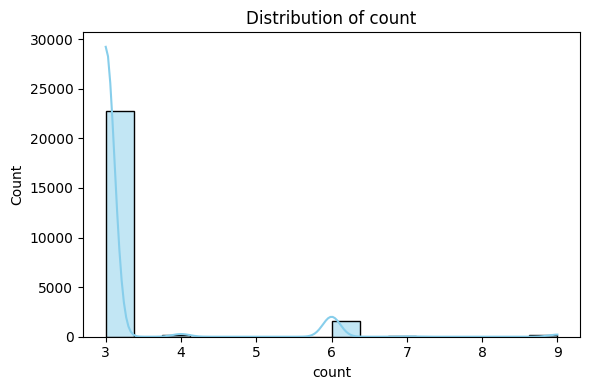

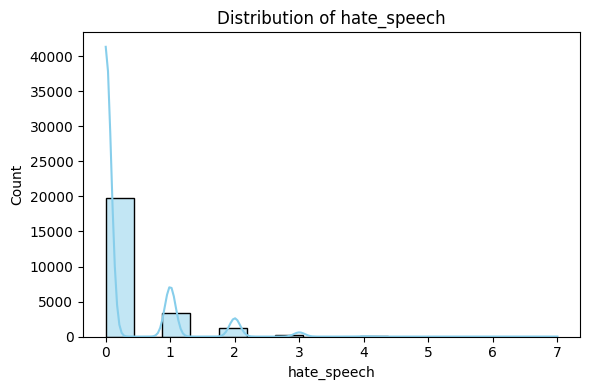

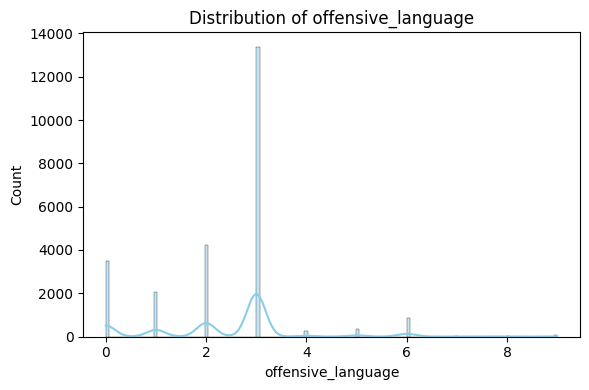

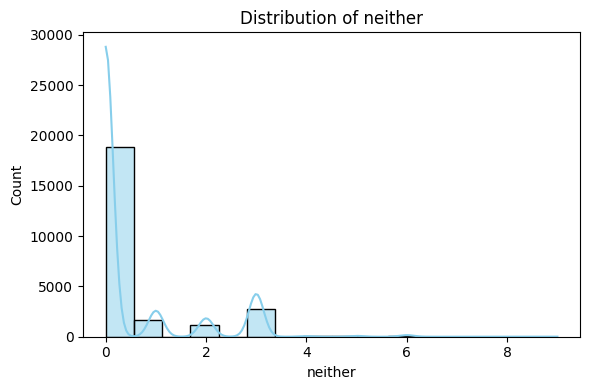

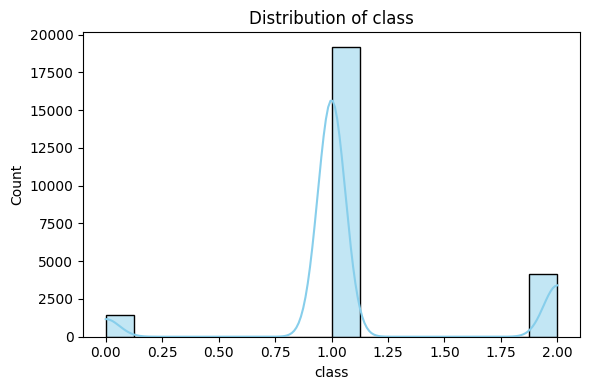

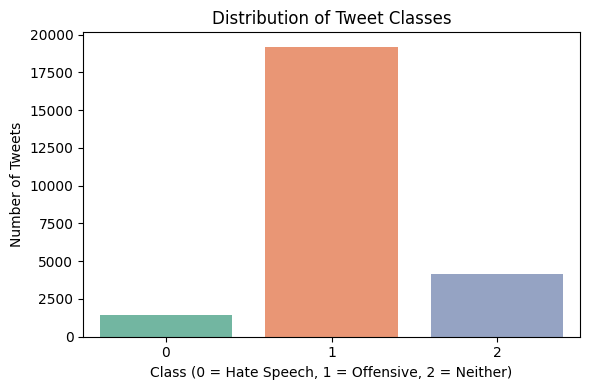

In [16]:
# Identify numeric columns, excluding 'tweet'
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col.lower() != 'tweet']

# Plot distributions for each numeric feature
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot class label distribution 
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette='Set2', legend=False)
plt.title("Distribution of Tweet Classes")
plt.xlabel("Class (0 = Hate Speech, 1 = Offensive, 2 = Neither)")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

For the count variable, the vast majority of entries have 3 reviewers with a small sub-population of 6 reviewers. For any given tweet, we should expect that the integers in the hate_speech, offensive_language, and neither columns sum to the value of the count column. It's clear from these columns that the majority of the tweets in the dataset fall somewhere around the offensive ranking, with roughly four thousand tweets ranked as hate speech. This is also evident in the class distribution, where the majority of tweets are ranked as offensive, followed by neither, with hate speech being the rarest category.  

In [18]:
# Check class balance
print(df['class'].value_counts(normalize=True))

class
1    0.774321
2    0.167978
0    0.057701
Name: proportion, dtype: float64


Quantifying the class distribution further, 77.4% of the tweets are offensive, 5.8% are hate speech, and 16.8% are neither. 

# __2. Feature Preprocessing - Tokenization__<br>

In [21]:
# Visualize some tweets
print(df['tweet'].sample(25, random_state=42).to_list())

['934 8616\ni got a missed call from yo bitch', 'RT @KINGTUNCHI_: Fucking with a bad bitch you gone need some money lil homie!', "RT @eanahS__: @1inkkofrosess lol my credit ain't no where near good , but I know the right man for the job .. that ho nice though!", "RT @Maxin_Betha Wipe the cum out of them faggot RT @80sbaby4life Contact lens is wildin can't see shit", "Niggas cheat on they bitch and don't expect no pay back WHATSOEVER. Yall just as naive as these bitches.", 'Mother asked what I wanted for Christmas this year. Replied with for her to not go crazy, and my sister to not be a bitch.', "That's real dedication. .. &#171;@arigold_88 This bitch got diarrhea and still here, shitting up the bathroom.&#187;", "Kiss IMO this conductor, it's 4:30 AM have some courtesy you bitch.", "My momma keep talking to me like bitch gtf I'm on Twitter.", 'RT @karlos_budah: I kno this bitch a thot she wanna meet my momma now', 'like a bitch pic is flirting nowadays', '@Nien_Nunb what did you searc

#### Should we remove or keep symbols?
My plan will be to remove most punctuation and non-alphanumeric symbols since they add noise and fragment tokens, but I'll keep or normalize those that carry sentiment or emphasis (such as “!”, “?”) and potentially map repeated punctuation to an additional feature. Emojis appear in some tweets in their html encodings, so I will likely have to create a binary has_emoji feature, as well as a feature to derive sentiment from any emojis present.

#### How should we parse hashtags and add them to features?
I plan to extract hashtags, split them into seperate words, and keep both the expanded text in the tweet body and a few additional features like has_hashtag and num_hashtags. I'll also consider keeping the # marker as a prefix token for the expanded words to differentiate the hashtag signal from standard text.

#### Should we remove URLs?
I will replace all URLs with a single placeholder token like "URL" instead of keeping raw strings or deleting outright them all together. The token preserves the fact that a link was shared, which may be a weak but sometimes useful signal, while avoiding high-variance, meaningless character sequences that hurt modeling. I’ll also include has_url and url_count features. The replacement will happen prior to punctuation cleanup to avoid corrupting links and to keep the token intact.

#### Should we remove userids?
I will replace all @username handles with a general "USER" token to preserve the interaction signal without leaking identities or exploding the vocabulary. I’ll also normalize retweet headers by converting leading patterns like RT @user into compact tokens ("RT" "USER"), and capture binary features such as is_retweet. This keeps the model aware of directed speech and retweet context, both of which may be correlated with toxicity.

#### Do either userid, hashtag or URLs help classify the dataset?
I would expect all three of these unique text types to provide some signal towards hate/offensive speech. Mentions capture targeted speech which may be more likely to be aggressive or hateful. Hashtags provide stance/affiliation information which may signal for hate/offensiveness depending on the type and quantity of text within them. Raw URLs seem unlikely to help, but the presence of the URL token could add a small signal. 

# __3. Feature Extraction I__<br>

This code prepares the text data in the 'tweet' column for analysis by performing basic tokenization and stopword removal using the NLTK library. It begins by downloading the necessary NLTK resources for tokenization (punkt and punkt_tab) and English stop words. The basic_tokenize function then takes each tweet, decodes any HTML entities, converts the text to lowercase for consistency, and splits it into individual word tokens using NLTK’s word_tokenize method. Common English stop words such as “the,” “and,” and “is” are removed to reduce noise and focus on more meaningful words. Finally, the function is applied to every tweet in the dataset, creating a new column called tokens that contains a cleaned list of words for each tweet.

In [32]:
# One-time downloads 
nltk.download('punkt')
nltk.download('punkt_tab') 
nltk.download('stopwords')

# Stopword list
stop_words = set(stopwords.words('english'))

# Basic Tokenization
def basic_tokenize(text: str):
    # Decode HTML entities and lowercase
    text = html.unescape(str(text)).lower()

    # Tokenize text into words
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [tok for tok in tokens if tok not in stop_words]

    return tokens

# Apply to tweet column
df['tokens'] = df['tweet'].apply(basic_tokenize)

# Inspect result
print(df[['tweet', 'tokens']].sample(20, random_state=42))

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/hunterworssam/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/hunterworssam/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hunterworssam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                   tweet  \
2281         934 8616\ni got a missed call from yo bitch   
15914  RT @KINGTUNCHI_: Fucking with a bad bitch you ...   
18943  RT @eanahS__: @1inkkofrosess lol my credit ain...   
16407  RT @Maxin_Betha Wipe the cum out of them faggo...   
13326  Niggas cheat on they bitch and don't expect no...   
12914  Mother asked what I wanted for Christmas this ...   
21457  That's real dedication. .. &#171;@arigold_88 T...   
12246  Kiss IMO this conductor, it's 4:30 AM have som...   
13083  My momma keep talking to me like bitch gtf I'm...   
19409  RT @karlos_budah: I kno this bitch a thot she ...   
24146              like a bitch pic is flirting nowadays   
4273   @Nien_Nunb what did you search? Gay redneck ep...   
9642   Halloween's over, and bitches still playing ro...   
23843                                      fucking queer   
22855  Why bitches quick to have a nigga baby, then b...   
10907  I stopped snapping on women and c

These token lists are far from perfect, and still require further processing to preserve the most signal possible for hate speech. Certain punctuation like commas and periods can be removed, but things like question marks or exclamations could be useful for hate speech determination. Additionally, identifying retweets, emojis, number of emojis and URLs could be important features as well and are worth handling with intention. These ideas will be addressed in the following feature extraction sections. 

# __4. Feature Extraction II__ <br>

This enhanced cleaning step builds on the basic tokenization by enforcing stricter text normalization rules. It decodes HTML entities, lowercases all text, and removes URLs, numbers, and non-letter symbols to retain only alphabetic content. After cleaning, it tokenizes the text into individual words and filters out both stop words and any tokens shorter than two characters to reduce noise. While this produces a simplified, uniform set of tokens, it does not preserve context from mentions (@user), retweets (RT), URLs, or emojis; all of which were intentionally stripped out here. In other words, this version prioritizes cleanliness and readability over semantic richness, leaving out potentially informative signals like targeted mentions, shared links, or emotional cues that emojis may convey.

In [36]:
# Enhanced Cleaning
def clean_tokens(text: str):
    # Lowercase and remove URLs + numbers + non-letter symbols
    text = html.unescape(str(text)).lower()
    text = re.sub(r'(https?://\S+|www\.\S+)', ' ', text)  # remove URLs
    text = re.sub(r'[\d]+', ' ', text)                    # remove digits
    text = re.sub(r'[^a-z\s]', ' ', text)                 # keep letters only

    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) >= 2]

    return tokens

# Apply enhanced cleaning
df['enhanced_tokens'] = df['tweet'].apply(clean_tokens)

# Preview a few rows
print(df[['tweet', 'enhanced_tokens']].sample(20, random_state=40))

                                                   tweet  \
21361  That bitch called on Thor for some strength. &...   
10878  I shoot at the pussy, I bust in the pussy I'm ...   
19491  RT @lamessican: I love when bitches throw shad...   
19919  RT @rickygervais: Humans are genetically close...   
13305      Niggahs need to keep there bitches in check '   
6512   @kitlange stop oppressing me! Have you heard o...   
17064  RT @RealNiggaSherm: I can't trust a bitch I ca...   
635    "fuck you you pussy ass hater go suck a dick a...   
21180                               Stop spoiling U fags   
19388              RT @juicygenie: Sheryl crow be my mom   
6813   @panchoftf I'm trying to catch diabetes so I'm...   
15926  RT @KINGTUNCHI_: Lowkey I put sum of these hoe...   
2739            @CallME__Jetson hoe ass nigga. &#128529;   
17921  RT @USABillOfRights: Psychological Warfare for...   
23088  Yall know Skip Bayless is about to slit his wr...   
12540              Lmaoooooo lil Dave yo

While it may be reasonable to strip away numbers and URLs, we can see in the output above that usernames and emojis are broken up and listed somehwta randomly throughout the token lists, destroying our ability to routinely detect when a tweet has a username, or when a retweet was made. These are potentially valuable features that I'd like to retain in a seperate token column to test my hypothesis of them being valuable for hate speech detection. In my code block below, I take an adjacent approach where prior to tokenization, I override any username with a "User" flag, emoji with an "emoji" flag, and retweet with a "RT" flag to help retain the signal of these components in the token lists. I considered doing the same for hashtags, but rather than flagging them I chose to simply handle them as standard text. For future optimization, it may be worth including a "HASHTAG" flag in addition to retaining the text.

In [38]:
# Make sure stopwords are defined
stop_words = set(stopwords.words('english'))

# Emoji unicode ranges (covers most common blocks)
EMOJI_CLASS = (
    u"\U0001F300-\U0001FAFF"  
    u"\U00002600-\U000026FF"
    u"\U00002700-\U000027BF"
    u"\uE000-\uF8FF"          # IOS emojis
)

def tokenize_contextual_simple(text: str):
    t = html.unescape(str(text))

    # Insert simple semantic tokens
    t = re.sub(r'^\s*RT\b', ' rt ', t, flags=re.IGNORECASE)   # retweets → 'rt'
    t = re.sub(r'@\w+', ' user ', t)                          # mentions → 'user'
    t = re.sub(r'(https?://\S+|www\.\S+)', ' ', t)            # URLs removed
    t = re.sub("[" + EMOJI_CLASS + "]", " emoji ", t)         # emojis → 'emoji'

    # drop digits + punctuation (keep letters/spaces)
    t = t.lower()
    t = re.sub(r'[\d]+', ' ', t)              # remove digits
    t = re.sub(r'[^a-z\s]', ' ', t)           # remove all non-letters 
    t = re.sub(r'\s+', ' ', t).strip()        # collapse whitespace

    # Tokenize 
    tokens = [tok for tok in t.split() if tok not in stop_words and len(tok) >= 2]
    return tokens

# Apply
df['thorough_tokens'] = df['tweet'].apply(tokenize_contextual_simple)

# Quick spot check
print(df[['tweet','thorough_tokens']].sample(20, random_state=40))

                                                   tweet  \
21361  That bitch called on Thor for some strength. &...   
10878  I shoot at the pussy, I bust in the pussy I'm ...   
19491  RT @lamessican: I love when bitches throw shad...   
19919  RT @rickygervais: Humans are genetically close...   
13305      Niggahs need to keep there bitches in check '   
6512   @kitlange stop oppressing me! Have you heard o...   
17064  RT @RealNiggaSherm: I can't trust a bitch I ca...   
635    "fuck you you pussy ass hater go suck a dick a...   
21180                               Stop spoiling U fags   
19388              RT @juicygenie: Sheryl crow be my mom   
6813   @panchoftf I'm trying to catch diabetes so I'm...   
15926  RT @KINGTUNCHI_: Lowkey I put sum of these hoe...   
2739            @CallME__Jetson hoe ass nigga. &#128529;   
17921  RT @USABillOfRights: Psychological Warfare for...   
23088  Yall know Skip Bayless is about to slit his wr...   
12540              Lmaoooooo lil Dave yo

This token list looks extremely similar to the enhanced_token lists above, but rather than having the retweet flag, username and emoji information lost witin the tokens, this list keeps those flags in place. Later we will directly test whether this provides any predictive value for detecting hate speech.

# __5. Feature Extraction III__ <br>

In [42]:
df.head()

,count,hate_speech,offensive_language,neither,class,tweet,tokens,enhanced_tokens,thorough_tokens
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,"[!, !, !, rt, @, mayasolovely, :, woman, n't, ...","[rt, mayasolovely, woman, complain, cleaning, ...","[rt, user, woman, complain, cleaning, house, m..."
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,"[!, !, !, !, !, rt, @, mleew17, :, boy, dats, ...","[rt, mleew, boy, dats, cold, tyga, dwn, bad, c...","[rt, user, boy, dats, cold, tyga, dwn, bad, cu..."
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,"[!, !, !, !, !, !, !, rt, @, urkindofbrand, da...","[rt, urkindofbrand, dawg, rt, sbaby, life, eve...","[rt, user, dawg, rt, user, ever, fuck, bitch, ..."
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,"[!, !, !, !, !, !, !, !, !, rt, @, c_g_anderso...","[rt, anderson, viva, based, look, like, tranny]","[rt, user, user, look, like, tranny]"
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,"[!, !, !, !, !, !, !, !, !, !, !, !, !, rt, @,...","[rt, shenikaroberts, shit, hear, might, true, ...","[rt, user, shit, hear, might, true, might, fak..."


This code uses scikit-learn’s TfidfVectorizer to convert the cleaned tweet tokens (both the enhanced and thorough sets) into numerical feature matrices suitable for machine learning. It creates two separate TF-IDF representations: one from the enhanced_tokens column and one from the thorough_tokens column. Because the tweets were already tokenized in earlier steps, the code passes the pre-tokenized lists directly to the vectorizer using identity functions so that the tokens aren’t reprocessed. Each resulting matrix (X_enhanced and X_thorough) has one row per tweet (24,783 total) and one column per unique token in that version’s vocabulary. The printed outputs show the shape of each matrix and report the vocabulary size M, which indicates how many unique words or tokens were identified across all tweets.

In [44]:
# Ensure token columns exist and are list-like
for col in ["enhanced_tokens", "thorough_tokens"]:
    if col not in df.columns:
        raise KeyError(f"Expected column '{col}' not found in df.")
    df[col] = df[col].apply(lambda x: x if isinstance(x, list) else ([] if x is None else list(x)))

# Identity functions so Vectorizer accepts pre-tokenized input
def identity(x): 
    return x

# Vectorizer config: no lowercasing/stopwords here (already done)
# no token_pattern (since we pass pre-tokenized lists), light dtype for memory
vec_cfg = dict(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    dtype=np.float32
)

# Enhanced tokens TF-IDF 
tfidf_enhanced = TfidfVectorizer(**vec_cfg)
X_enhanced = tfidf_enhanced.fit_transform(df["enhanced_tokens"])
M_enhanced = len(tfidf_enhanced.vocabulary_)

# Thorough tokens TF-IDF
tfidf_thorough = TfidfVectorizer(**vec_cfg)
X_thorough = tfidf_thorough.fit_transform(df["thorough_tokens"])
M_thorough = len(tfidf_thorough.vocabulary_)

# Report shapes and vocabulary sizes
print("Enhanced tokens TF-IDF:")
print(f"  X_enhanced shape: {X_enhanced.shape}  (rows x cols)")
print(f"  Vocabulary size (M): {M_enhanced}")

print("\nThorough tokens TF-IDF:")
print(f"  X_thorough shape: {X_thorough.shape}  (rows x cols)")
print(f"  Vocabulary size (M): {M_thorough}")

# Assert expected row count
assert X_enhanced.shape[0] == 24783 and X_thorough.shape[0] == 24783, "Row count mismatch (expected 24,783)."

Enhanced tokens TF-IDF:
  X_enhanced shape: (24783, 31287)  (rows x cols)
  Vocabulary size (M): 31287

Thorough tokens TF-IDF:
  X_thorough shape: (24783, 19855)  (rows x cols)
  Vocabulary size (M): 19855


The thorough_tokens vocabulary is much smaller because the preprocessing above collapses many rare, noisy tokens into a few standardized ones. In the enhanced version, every distinct handle, emoji, and retweet header appears as its own token, inflating the vocabulary with thousands of one-offs. In the thorough version, all mentions become user, all emojis become emoji, and retweet markers become rt, which merges those variants into just a few tokens. Together, these steps reduce sparsity and compress the vocabulary from ~31k to ~19k while hopefully preserving the key signals (to be determined).

# __6. Feature Ranking and Knowledge Generation__<br>

In this section, I use two complementary approaches to identify which words or tokens are most strongly associated with hate speech (class 0). First, I apply the chi-squared (χ²) test to measure the statistical relationship between each token and the hate-speech label. Then, I train a logistic regression model to examine which features most influence the model’s predictions for that class. Comparing the results across both methods, and across the enhanced_tokens and thorough_tokens representations, helps evaluate how consistent and informative each preprocessing approach is in capturing the language patterns linked to hate speech.

In [52]:
y = df['class']

def rank_features(X, vectorizer, y, label_name):
    feature_names = np.array(vectorizer.get_feature_names_out())

    # χ² test
    chi2_scores, _ = chi2(X, y == 0)      # test association with "hate speech"
    chi2_ranking = feature_names[np.argsort(chi2_scores)[::-1]]

    # Logistic Regression
    logreg = LogisticRegression(max_iter=200, solver='liblinear')
    logreg.fit(X, y)
    # coefficients for class 0
    coef = logreg.coef_[0]
    logreg_ranking = feature_names[np.argsort(coef)[::-1]]

    print(f"\nTop χ² features for hate speech ({label_name}):")
    print(chi2_ranking[:15])

    print(f"\nTop logistic-regression features for hate speech ({label_name}):")
    print(logreg_ranking[:15])

    print(f"\nLowest logistic-regression features (least indicative of hate speech):")
    print(logreg_ranking[-15:])

# Run for both token sets
rank_features(X_enhanced, tfidf_enhanced, y, "enhanced_tokens")
print(f'________________________________________________________________________________')
rank_features(X_thorough, tfidf_thorough, y, "thorough_tokens")


Top χ² features for hate speech (enhanced_tokens):
['faggot' 'nigger' 'niggers' 'faggots' 'fag' 'white' 'fags' 'spic' 'queer'
 'dyke' 'racist' 'jew' 'wetback' 'coon' 'whitey']

Top logistic-regression features for hate speech (enhanced_tokens):
['faggot' 'nigger' 'faggots' 'white' 'niggers' 'fag' 'fags' 'nigga' 'dyke'
 'niggas' 'queer' 'kill' 'racist' 'coon' 'spic']

Lowest logistic-regression features (least indicative of hate speech):
['talk' 'brownies' 'let' 'ho' 'rt' 'yellow' 'yankees' 'birds' 'charlie'
 'bird' 'hoe' 'hoes' 'pussy' 'bitches' 'bitch']
________________________________________________________________________________

Top χ² features for hate speech (thorough_tokens):
['faggot' 'nigger' 'niggers' 'fag' 'faggots' 'white' 'fags' 'spic' 'queer'
 'dyke' 'racist' 'coon' 'jew' 'wetback' 'whitey']

Top logistic-regression features for hate speech (thorough_tokens):
['faggots' 'white' 'faggot' 'niggers' 'nigger' 'fags' 'fag' 'nigga'
 'niggas' 'dyke' 'queer' 'racist' 'kill' 'c

Both the χ² and logistic regression feature ranking methods identified nearly identical sets of tokens as being most strongly associated with hate speech (class 0). The top-ranked features across both approaches consist of explicit slurs and highly derogatory terms; language patterns that clearly drive model separation between hate speech and other classes. This alignment indicates that both the statistical and model-based techniques are capturing the same linguistic signal, confirming consistency between the preprocessing, tokenization, and feature extraction pipelines. It's very encouraging that the chi-squared approach yielded similar results as the logistic regression. Given the simplicity of the chi-squared approach, I'd start with that option in the future. 

Across the two preprocessing versions (enhanced_tokens vs. thorough_tokens), the overlap in high-ranking features remains strong, suggesting that the standardization of usernames, emojis, and retweet markers did not dilute the core discriminatory vocabulary. The only minor differences lie in the lowest-weighted features, where tokens like rt, yankees, birds, and bitch appear. These tend to represent neutral conversational language or contextually offensive words that occur across multiple classes, not just hate speech.

# __7. Classification__<br>

In this section, I evaluate model performance using two common and complementary text classification algorithms: Linear Support Vector Machine (SVM) and Multinomial Naïve Bayes. Both models are well-suited for high-dimensional, sparse representations like the TF-IDF matrices created from the tweet data. SVMs tend to perform strongly when classes are separable in feature space, leveraging large-margin decision boundaries, while Naïve Bayes provides a simple probabilistic baseline that performs surprisingly well on word-frequency data. Running both models on the enhanced and thorough token representations allows comparison of how the different preprocessing strategies affect predictive performance on imbalanced hate-speech data.

In [57]:
# Define stratified 5-fold CV since hate speech class is imbalanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0)
}

# Define models
models = {
    "LinearSVC": LinearSVC(dual="auto"),
    "MultinomialNB": MultinomialNB()
}

# Store results
results = []

for name, model in models.items():
    for rep_name, X in [("Enhanced", X_enhanced), ("Thorough", X_thorough)]:
        print(f"\nRunning {name} on {rep_name} tokens...")
        scores = cross_validate(model, X, df["class"], cv=cv, scoring=scoring, n_jobs=-1)
        results.append({
            "Model": name,
            "Representation": rep_name,
            "Accuracy": np.mean(scores['test_accuracy']),
            "Precision (Macro)": np.mean(scores['test_precision_macro']),
            "Recall (Macro)": np.mean(scores['test_recall_macro']),
            "F1 (Macro)": np.mean(scores['test_f1_macro'])
        })

# Convert to DataFrame for easy viewing
cv_results = pd.DataFrame(results)
print("\n=== 5-Fold Cross-Validation Results ===")
print(cv_results.round(4))


Running LinearSVC on Enhanced tokens...

Running LinearSVC on Thorough tokens...

Running MultinomialNB on Enhanced tokens...

Running MultinomialNB on Thorough tokens...

=== 5-Fold Cross-Validation Results ===
           Model Representation  Accuracy  Precision (Macro)  Recall (Macro)  \
0      LinearSVC       Enhanced    0.8991             0.7665          0.6874   
1      LinearSVC       Thorough    0.8981             0.7604          0.6823   
2  MultinomialNB       Enhanced    0.7987             0.5797          0.3834   
3  MultinomialNB       Thorough    0.8058             0.5774          0.3983   

   F1 (Macro)  
0      0.7093  
1      0.7032  
2      0.3821  
3      0.4047  


The 5-fold cross-validation results show that the Linear SVM clearly outperformed the Multinomial Naïve Bayes across all metrics, regardless of whether the model used the enhanced or thorough token representations. Both SVM runs achieved around 89.9% accuracy and 0.71 macro F1, indicating strong overall performance and good balance between precision and recall. In contrast, Naïve Bayes achieved roughly 80% accuracy and 0.39–0.40 macro F1, reflecting weaker performance on minority classes such as hate speech.
To interpret the metrics:

Accuracy measures the overall proportion of correctly classified tweets, but it can be misleading when classes are imbalanced because majority classes dominate the score.

Precision (macro) averages the precision across all classes, indicating how often predicted labels are correct. High precision means fewer false positives.

Recall (macro) averages the recall per class, showing how effectively the model captures all true instances of each label. High recall means fewer false negatives.

F1 (macro) is the harmonic mean of precision and recall, giving a balanced view of model performance across classes, which is especially useful for imbalanced datasets.

The near-identical results between the enhanced and thorough tokenizations suggest that standardizing usernames, emojis, and retweets had little impact on model generalization, with the main predictive signal coming from the actual word content. Overall, the Linear SVM handled the sparse, high-dimensional TF-IDF data much better, achieving stronger balance between identifying hate speech correctly and avoiding misclassification of non-hate content.

# __8. Unsupervised Learning__<br>

In this section, I explore the dataset using unsupervised learning to see whether natural clusters exist within the text data without using the predefined class labels. By applying K-Means clustering to both the enhanced and thorough TF-IDF representations, the goal is to evaluate how well the tweets group together based on linguistic similarity alone. Clustering performance is assessed using metrics such as the Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), and Silhouette Score, which together measure how closely the clusters align with the known classes (hate speech, offensive speech, and neither) and how well-separated the resulting clusters are in feature space.

In [61]:
# True labels
y_true = df["class"]

# Define function for evaluation
def evaluate_clustering(X, y_true, label):
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)
    sil = silhouette_score(X, cluster_labels, sample_size=2000)

    return {
        "Representation": label,
        "ARI": ari,
        "NMI": nmi,
        "Silhouette": sil
    }

# Run for both tokenizations
results = []
results.append(evaluate_clustering(X_enhanced, y_true, "Enhanced"))
results.append(evaluate_clustering(X_thorough, y_true, "Thorough"))

# Present results
clustering_results = pd.DataFrame(results)
print("=== Clustering Evaluation Results ===")
print(clustering_results.round(4))

=== Clustering Evaluation Results ===
  Representation     ARI     NMI  Silhouette
0       Enhanced -0.0610  0.1358      0.0049
1       Thorough -0.0501  0.0117      0.0093


The clustering results show very low alignment between the unsupervised K-Means clusters and the known class labels. Both the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are close to zero (and slightly negative for ARI), which means the discovered clusters are no better than random with respect to the hate-speech, offensive, and neutral categories. Likewise, the silhouette scores near 0 indicate poor cluster cohesion and separation, suggesting that tweets from different classes occupy overlapping regions in the TF-IDF feature space.

This outcome is not surprising since hate and offensive language share much of the same vocabulary, and even neutral tweets can contain similar contextual terms, making purely unsupervised text clustering difficult. The results also imply that adding more clusters would likely not yield meaningful new categories since K-Means fails to reveal clear substructures beyond the existing class distinctions. Let's visualize an elbow curve to better determine how a large K would impact the clustering seperation. 

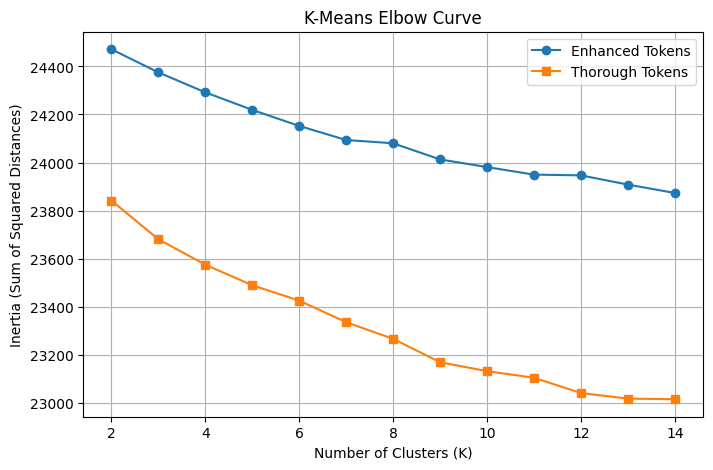

In [63]:
# Define range of K values
K_range = range(2, 15)

# Function to compute inertia (sum of squared distances to centroids)
def compute_inertia(X, label):
    inertias = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    return inertias

# Compute for both token representations
inertia_enhanced = compute_inertia(X_enhanced, "Enhanced")
inertia_thorough = compute_inertia(X_thorough, "Thorough")

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_enhanced, marker='o', label='Enhanced Tokens')
plt.plot(K_range, inertia_thorough, marker='s', label='Thorough Tokens')
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.legend()
plt.grid(True)
plt.show()

The elbow curve demonstrates a steady, near-linear decrease in inertia across increasing K, with no obvious inflection point where cluster cohesion meaningfully improves. This pattern suggests that the tweets form a continuous mass of sentiment rather than distinct separable groups. In other words, hate, offensive, and neutral language share enough overlapping vocabulary that K-Means fails to uncover strong natural boundaries in the TF-IDF feature space. Both the enhanced and thorough token representations behave similarly, further reinforcing that the dataset’s structure is inherently widespread. Because of this density and overlap, unsupervised methods like K-Means are unlikely to produce interpretable or stable sub-clusters beyond the original three human-defined labels.

Given how large our TF-IDF feature matrices are, I'm curious if we can improvde performance or silhouette score by reducing the dimensionality to, say, the top 10 principal components of the TF-IDF matrices. Let's redo the two steps above, including the classification accuracy and the elbow curve, using the reduced dataset. 

In [66]:
# Using TruncatedSVD (PCA for sparse data)
svd = TruncatedSVD(n_components=10, random_state=42)

def cluster_with_svd(X, y_true, label):
    # Reduce dimensionality
    X_reduced = svd.fit_transform(X)
    
    # Run K-Means with 3 clusters
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_reduced)

    # Evaluate clustering
    ari = adjusted_rand_score(y_true, clusters)
    nmi = normalized_mutual_info_score(y_true, clusters)
    sil = silhouette_score(X_reduced, clusters)

    return {
        "Representation": label,
        "ARI": ari,
        "NMI": nmi,
        "Silhouette": sil
    }

# Run for both tokenizations
results_svd = []
results_svd.append(cluster_with_svd(X_enhanced, df["class"], "Enhanced + PCA(10)"))
results_svd.append(cluster_with_svd(X_thorough, df["class"], "Thorough + PCA(10)"))

clustering_svd_results = pd.DataFrame(results_svd)
print("=== Clustering Results After Dimensionality Reduction ===")
print(clustering_svd_results.round(4))

=== Clustering Results After Dimensionality Reduction ===
       Representation     ARI     NMI  Silhouette
0  Enhanced + PCA(10) -0.0625  0.1351      0.1972
1  Thorough + PCA(10) -0.0482  0.0106      0.2575


We are still seeing extremely poor classification performance from the clustering when using the reduced dimensions, implying we still have tremendous overlap between our three known classes. We do however see a modest improvement in silhouette score for both vectorization approaches. While these values still indicate weak overall separation between clusters, the improvement suggests that projecting the data into a lower-dimensional latent space helped reveal some underlying structure that K-Means could better exploit. In other words, removing noise and redundancy from the high-dimensional TF-IDF vectors enhanced cluster compactness and inter-cluster separation slightly, though not enough to indicate strongly defined or well-isolated groupings.

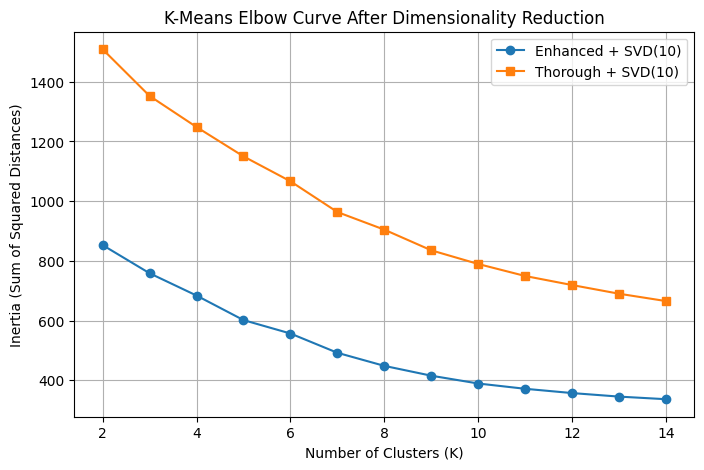

In [68]:
# Reduce the dimensionality
svd = TruncatedSVD(n_components=10, random_state=42)
X_reduced_enhanced = svd.fit_transform(X_enhanced)
X_reduced_thorough = svd.fit_transform(X_thorough)

# Range of K values to test
K_range = range(2, 15)

def compute_inertia(X_reduced):
    inertias = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_reduced)
        inertias.append(kmeans.inertia_)
    return inertias

inertia_enhanced_svd = compute_inertia(X_reduced_enhanced)
inertia_thorough_svd = compute_inertia(X_reduced_thorough)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_enhanced_svd, marker='o', label='Enhanced + SVD(10)')
plt.plot(K_range, inertia_thorough_svd, marker='s', label='Thorough + SVD(10)')
plt.title("K-Means Elbow Curve After Dimensionality Reduction")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.legend()
plt.grid(True)
plt.show()

After reducing the TF-IDF matrices to 10 latent components using Truncated SVD, the elbow curve on the reduced feature space again shows a smooth, monotonic decline in inertia, indicating no clear inflection point or “natural” number of clusters. This suggests that even after dimensionality reduction, the tweets remain part of a continuous, overlapping feature space rather than forming distinct groups.

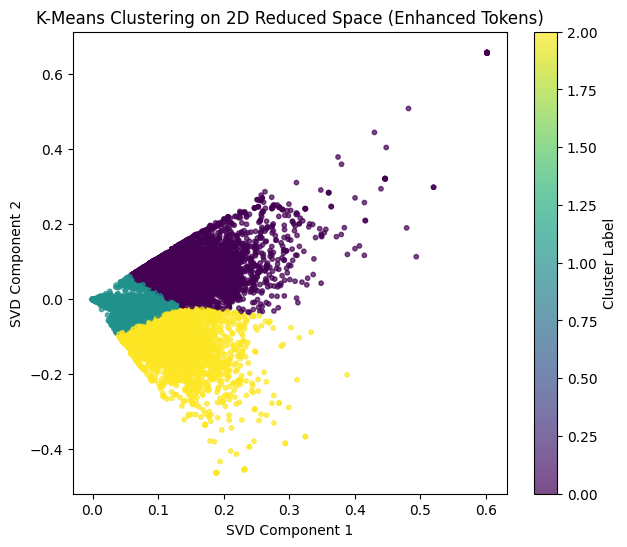

In [71]:
# Project to 2D for visualization
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d_enhanced = svd_2d.fit_transform(X_enhanced)

# Run K-Means with 3 clusters (for visual simplicity)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_2d_enhanced)

# Plot clusters
plt.figure(figsize=(7,6))
scatter = plt.scatter(
    X_2d_enhanced[:, 0],
    X_2d_enhanced[:, 1],
    c=clusters,
    cmap='viridis',
    s=10,
    alpha=0.7
)
plt.title("K-Means Clustering on 2D Reduced Space (Enhanced Tokens)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.show()

The 2-D cluster plot of the first two SVD components reveals that K-Means identifies three visibly distinct regions in the reduced feature space, indicating that the dimensionality reduction captured meaningful variance in the data. These clusters likely reflect broader thematic differences across tweets, potentially distinguishing hate, offensive, and neutral language, though some overlap is still expected in higher dimensions. Overall, the visualization suggests that while strict boundaries remain imperfect, semantic clustering in reduced space does recover some natural separation within the dataset.

# __9. Analysis__<br>

##### Feature Exploration
Initial exploration of the dataset revealed a high degree of textual variety and noise common in social media text, including slang, misspellings, and embedded symbols such as URLs, emojis, and user mentions. The class distribution was also imbalanced, with hate speech being the minority class. These characteristics informed subsequent preprocessing decisions to normalize tokens while preserving contextual cues that could help distinguish hateful or offensive content.

##### Feature Preprocessing
Text preprocessing focused on cleaning and normalization. Two main strategies were implemented: an enhanced approach that standardized words and removed URLs, punctuation, and stop words; and a thorough approach that further normalized usernames, retweets, and emojis into consistent tokens. This dual-representation approach provided a way to assess how aggressive normalization versus richer contextual preservation would impact downstream modeling performance. The underlying theory here was that the presence of more retweets or usernames would imply aggression, potentially leading to a higher probability of hate speech. 

##### Feature Extraction and Improvements
TF-IDF vectorization transformed the cleaned tweets into numerical feature matrices for modeling. The enhanced tokenization produced a larger vocabulary (31K terms), while the thorough approach, after collapsing user, emoji, and retweet markers, yielded a smaller, more compact feature set (19K terms). This confirmed that normalization effectively reduced sparsity by merging semantically similar patterns. Both representations were retained for subsequent evaluation to balance interpretability and feature richness.

##### Feature Ranking
Feature importance was analyzed using both the χ² statistic and logistic regression coefficients. Across both vectorization schemes, the top-ranked features associated with hate speech were nearly identical, including strongly discriminatory slurs and other offensive terms, confirming model agreement. Least indicative terms were more conversational or neutral. The alignment between methods and between token sets demonstrated the consistency and robustness of key linguistic indicators of hate speech.

##### Supervised Learning
Supervised modeling compared LinearSVC and Multinomial Naive Bayes under 5-fold cross-validation while addressing class imbalance. The LinearSVC models performed best, achieving ~0.90 accuracy and macro F1 scores around 0.71 for both enhanced and thorough tokenizations. Naive Bayes underperformed due to its simplifying assumptions about feature independence. Overall, the strong SVM performance highlights that contextual weighting of features (via TF-IDF) and regularization were effective for this classification task.

##### Unsupervised Learning
Unsupervised clustering with K-Means showed limited separability in the original TF-IDF space, with near-zero silhouette scores. However, applying Truncated SVD to reduce the data to 10 latent components improved silhouette scores modestly (to 0.197–0.258) and revealed more visible structure in the 2D projection. While full separation between hate, offensive, and neutral speech remained imperfect, dimensionality reduction uncovered partial semantic differences, suggesting that additional features could further improve class distinction in future iterations.

# References
[1] Christopher M. Bishop. Neural Networks for Pattern Recognition. Oxford University Press, 1995.<br><br>
[2] Christopher Bishop. Pattern Recognition and Machine Learning. Springer, 2006. isbn: 0387310738.<br><br>
[3] Barry J. Shepherd C. Wayne Brown. Graphics File Formats: Reference and Guide. Manning
Publications, 1995. isbn: 1884777007.<br><br>
[4] Thomas H. Cormen et al. Introduction to Algorithms. 3rd. MIT Press, 2009. isbn: 780262033848.<br><br>
[5] W. R. Dillon and M. Goldstein. Multivariate Analysis Method and Applications. New York, NY:
John Wiley Sons, Inc, 1984.<br><br>
[6] Richard O. Duda, Peter E. Hart, and David G. Stork. Pattern Classification. 2nd. Wiley-
Interscience, 2000.<br><br>
[7] Duin et al. PRTools. https://cmp.felk.cvut.cz/cmp/software/stprtool/index.html.<br><br>
[8] L. Euler. “Nova Acta Acad. Sci. Petrop”. In: (1960).<br><br>
[9] R.A. Fisher. “The use of Multiple Measurements in Taxonomic Problems”. In: Proceedings of
Annals of Eugenics 7 (1936), pp. 179–188.<br><br>
[10] Vojtech Franc and Vaclav Hlavac. Statistical Pattern Recognition Toolbox. https://cmp.felk.
cvut.cz/cmp/software/stprtool/index.html.<br><br>
[11] Keinosuke Fukunaga. Introduction to Statistical Pattern Recognition. 1st. Academic Press, 1972.
isbn: 0122698509.<br><br>
[12] Keinosuke Fukunaga. Introduction to Statistical Pattern Recognition. 2nd. Academic Press, 1990.
isbn: 0122698517.<br><br>
[13] Herman H. Goldstine. A History of Numerical Analysis from the 16th through the 19th Century.
Springer New York, 1977. isbn: 978-0-387-90277-7.<br><br>
[14] H. Hotelling. “Analysis of a complex of statistical variables into principal components”. In: Jour-
nal of Educational Psychology 24 (1933), pp. 417–441.<br><br>
[15] Averill Law. Simulation Modeling and Analysis. 5th. Mcgraw-hill Series in Industrial Engineering
and Management, 2014.<br><br>
[16] Machine Learning at Waikato University. https://www.cs.waikato.ac.nz/~ml/index.html.<br><br>
[17] James D. Murry and William vanRyper. Encyclopedia of Graphics File Formats: The Com-
plete Reference on CD-ROM with Links to Internet Resources. 2nd. O’Reilly Media, 1996. isbn:
1565921615.<br><br>
[18] F. Pedregosa et al. “Scikit-learn: Machine Learning in Python”. In: Journal of Machine Learning
Research 12 (2011), pp. 2825–2830.<br><br>
[19] Casey J. Richards et al. “Multimodal data fusion using signal/image processing methods for
multi-class machine learning”. In: Signal Processing, Sensor/Information Fusion, and Target
Recognition XXXII. Ed. by Ivan Kadar, Erik P. Blasch, and Lynne L. Grewe. Vol. 12547. Inter-
national Society for Optics and Photonics. SPIE, 2023, 125470N. doi: 10.1117/12.2664987.
url: https://doi.org/10.1117/12.2664987.<br><br>
[20] Benjamin M. Rodriguez. “Multi-Class Classification for Identifying JPEG Steganography Em-
bedding Methods”. PhD thesis. Air Force Institute of Technology, 2008. url: https://scholar.
afit.edu/cgi/viewcontent.cgi?article=3642&context=etd.<br><br>
[21] Stuart Russell and Peter Norvig. Artificial Intelligence: A Modern Approach. 4th. Prentice Hall,
2020.<br><br>
[22] Amir Saeed et al. “Reinforcement learning application to satellite constellation sensor tasking”.
In: Artificial Intelligence and Machine Learning for Multi-Domain Operations Applications V.
Ed. by Latasha Solomon and Peter J. Schwartz. Vol. 12538. International Society for Optics and
Photonics. SPIE, 2023, 125381B. doi: 10.1117/12.2664346. url: https://doi.org/10.1117/
12.2664346.<br><br>
[23] C. E. Shannon. “Programming a Computer for Playing Chess”. In: Philosophical Magazine.
7th ser. 41.314 (1950).<br><br>
[24] Richard S. Sutton and Andrew G. Barto. Reinforcement learning: An introduction. MIT Press,
2018.<br><br>
[25] Sergios Theodoridis and Konstantinos Koutroumbas. Pattern Recognition. 3rd. Academic Press,
2006. isbn: 0123695317.<br><br>
[26] Alan M. Turing. “Computing Machinery and Intelligence”. In: Mind 59.236 (1950), pp. 433 –460.<br><br>
[27] P. Winston. Artificial Intelligence. 3rd. Pearson, 1992.<br><br>